## importing necessary libraries

In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import tweepy
from tweepy import OAuthHandler
import requests as r
from bs4 import BeautifulSoup
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression , LinearRegression
from sklearn.metrics import accuracy_score

## using requests to get the link of the TSV file 

In [349]:
response = r.get('https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv')

**opening a file naming it neuralnet_predictions as a tsv file and writing the content retrieved by the link using requests in this file**

In [350]:
with open('neuralnet_predictions.tsv', 'wb') as f:
    f.write(response.content)

## Assessing results:

## in twitter dataframe:
**quality issues:**

1- unneeded columns with too many nan values (in_reply_to_status_id,in_reply_to_user_id,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp)

2- rating_denominator column has a denominator of value 0 in a row and can be changed by putting the mean

3- missing values in needed columns (name,expanded_urls,possibly_sensitive,possibly_sensitive_appealable)

4- timestamp column is not in datatime type

5- Juckson name is written incorrectly and must be edited to Jackson

6- source is in html 'a' tag format

7- present of retweets in the data

**tidiness issues**

1- text column has URL in the end which can be used for merging

2- doggo,floofer,pupper,puppo columns can be grouped into one column that can be used for analysis

3- from source column i can extract what device was the tweet published from

## in tweets dataframe:
**quality issues:**

1- id_str is displayed as integers and not strings as it should

2-missing values in many columns 

3- present of retweets

**tidiness issues**

1-display text range column is in two variable the min and max and can be divided into two columns

2-urls can be extracted from full text

## importing data

In [351]:
import pandas as pd
neuralnet_data = pd.read_csv('neuralnet_predictions.tsv', sep='\t')
tweet = pd.read_json("tweet-json.json", lines=True)  
twitter = pd.read_csv('twitter-archive-enhanced.csv')

**function to caculate the nan in a dataframe in precentage**

In [352]:
def nan_values(dataframe):
    return dataframe.isna().sum() / dataframe.shape[0] * 100

in the twitter dataframe there is too much nan values in many columns

In [353]:
nan_values(twitter)

tweet_id                       0.000000
in_reply_to_status_id         96.689304
in_reply_to_user_id           96.689304
timestamp                      0.000000
source                         0.000000
text                           0.000000
retweeted_status_id           92.317487
retweeted_status_user_id      92.317487
retweeted_status_timestamp    92.317487
expanded_urls                  2.504244
rating_numerator               0.000000
rating_denominator             0.000000
name                          31.621392
doggo                         95.882852
floofer                       99.575552
pupper                        89.091681
puppo                         98.726655
dtype: float64

## visuallizing the rating denominator column
there is rating denominator of values 0 here which isn't logical

array(["@jonnysun @Lin_Manuel ok jomny I know you're excited but 960/00 isn't a valid rating, 13/10 is tho"],
      dtype=object)

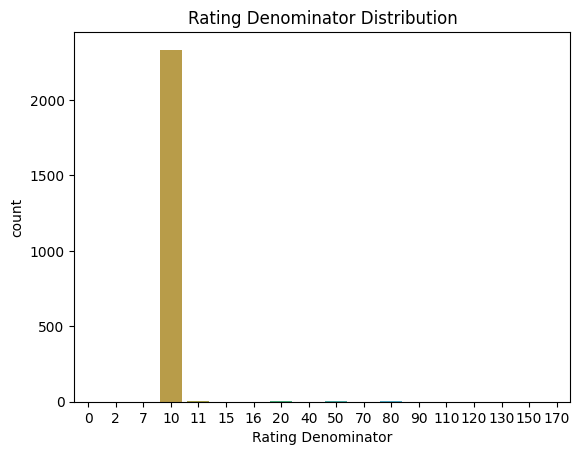

In [354]:
sns.barplot(x=twitter['rating_denominator'].value_counts().index,y=twitter['rating_denominator'].value_counts().values)
plt.title('Rating Denominator Distribution')
plt.xlabel('Rating Denominator')
plt.ylabel('count')
twitter[twitter['rating_denominator']== 0]['text'].values

## timestamp column is in object data type, it must be datetime

In [355]:
twitter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        1611 non-null   object 
 13  doggo                       97 no

## text column has URL in the end which can be used for merging

In [356]:
twitter['text'][0]

"This is Phineas. He's a mystical boy. Only ever appears in the hole of a donut. 13/10 https://t.co/MgUWQ76dJU"

## Juckson name is written incorrectly and it should have been Jackson

In [357]:
twitter[twitter['name'] == 'Juckson']['name'].values

array(['Juckson'], dtype=object)

## source is in html 'a' tag format

In [358]:
twitter['source']

0       <a href="http://twitter.com/download/iphone" r...
1       <a href="http://twitter.com/download/iphone" r...
2       <a href="http://twitter.com/download/iphone" r...
3       <a href="http://twitter.com/download/iphone" r...
4       <a href="http://twitter.com/download/iphone" r...
                              ...                        
2351    <a href="http://twitter.com/download/iphone" r...
2352    <a href="http://twitter.com/download/iphone" r...
2353    <a href="http://twitter.com/download/iphone" r...
2354    <a href="http://twitter.com/download/iphone" r...
2355    <a href="http://twitter.com/download/iphone" r...
Name: source, Length: 2356, dtype: object

## id_str column should be in string data type

In [359]:
tweet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   created_at                     2354 non-null   datetime64[ns, UTC]
 1   id                             2354 non-null   int64              
 2   id_str                         2354 non-null   int64              
 3   full_text                      2354 non-null   object             
 4   truncated                      2354 non-null   bool               
 5   display_text_range             2354 non-null   object             
 6   entities                       2354 non-null   object             
 7   extended_entities              2073 non-null   object             
 8   source                         2354 non-null   object             
 9   in_reply_to_status_id          78 non-null     float64            
 10  in_reply_to_status_id_st

In [360]:
nan_values(tweet)

created_at                         0.000000
id                                 0.000000
id_str                             0.000000
full_text                          0.000000
truncated                          0.000000
display_text_range                 0.000000
entities                           0.000000
extended_entities                 11.937128
source                             0.000000
in_reply_to_status_id             96.686491
in_reply_to_status_id_str         96.686491
in_reply_to_user_id               96.686491
in_reply_to_user_id_str           96.686491
in_reply_to_screen_name           96.686491
user                               0.000000
geo                              100.000000
coordinates                      100.000000
place                             99.957519
contributors                     100.000000
is_quote_status                    0.000000
retweet_count                      0.000000
favorite_count                     0.000000
favorited                       

**important info can be extracted from entities column to make other columns**

In [361]:
tweet['entities'][0]

{'hashtags': [],
 'symbols': [],
 'user_mentions': [],
 'urls': [],
 'media': [{'id': 892420639486877696,
   'id_str': '892420639486877696',
   'indices': [86, 109],
   'media_url': 'http://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg',
   'media_url_https': 'https://pbs.twimg.com/media/DGKD1-bXoAAIAUK.jpg',
   'url': 'https://t.co/MgUWQ76dJU',
   'display_url': 'pic.twitter.com/MgUWQ76dJU',
   'expanded_url': 'https://twitter.com/dog_rates/status/892420643555336193/photo/1',
   'type': 'photo',
   'sizes': {'large': {'w': 540, 'h': 528, 'resize': 'fit'},
    'thumb': {'w': 150, 'h': 150, 'resize': 'crop'},
    'small': {'w': 540, 'h': 528, 'resize': 'fit'},
    'medium': {'w': 540, 'h': 528, 'resize': 'fit'}}}]}

## Cleaning stage:
**starting with twitter dataframe**

In [362]:
twitter_clean = twitter.copy()

## getting rid of retweets

In [363]:
## remove retweets by choosing tweets that has nan retweeted_status_id
twitter_clean = twitter_clean[twitter_clean['retweeted_status_id'].isna()]

In [364]:
## a function to merge the dog types into one column
def dog_type(row):
    if row['doggo'] == 'doggo':
        return 'doggo'
    elif row['floofer'] == 'floofer':
        return 'floofer'
    elif row['pupper'] == 'pupper':
        return 'pupper'
    elif row['puppo'] == 'puppo':
        return 'puppo'
    else:
        return 'None'

made a function to merge the dog types into one column that can be used for modeling and predictions and also analysis
and filled the other nan rows with none to exclude this column from dropping columns in the future

In [365]:
twitter_clean[['doggo', 'floofer', 'pupper', 'puppo']].fillna('None',inplace=True)
twitter_clean['dog_type'] = twitter_clean.apply(dog_type, axis=1)

C:\Users\Hp\AppData\Local\Temp\ipykernel_19772\798267666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  twitter_clean[['doggo', 'floofer', 'pupper', 'puppo']].fillna('None',inplace=True)


a function for choosing the columns that has too many nan values that will not be in use for analysis or modeling

In [366]:
def dropping_nan_columns(dataframe):
    columns_to_drop = []
    for column in dataframe.columns:
        if dataframe[column].isna().sum() / dataframe.shape[0] * 100 > 50:
            columns_to_drop.append(column)
    return columns_to_drop

In [367]:
columns_to_drop = dropping_nan_columns(twitter_clean)
twitter_clean.drop(columns=columns_to_drop, inplace=True)

filling the names that was not mentioned or Unavaliable with Unknown

In [368]:
twitter_clean['name'].fillna('Unknown',inplace=True)

In [369]:
twitter_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2355
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_id            2175 non-null   int64 
 1   timestamp           2175 non-null   object
 2   source              2175 non-null   object
 3   text                2175 non-null   object
 4   expanded_urls       2117 non-null   object
 5   rating_numerator    2175 non-null   int64 
 6   rating_denominator  2175 non-null   int64 
 7   name                2175 non-null   object
 8   dog_type            2175 non-null   object
dtypes: int64(3), object(6)
memory usage: 169.9+ KB


the unvalid values in name column is replaced with unknown

In [370]:
twitter_clean['name'].replace({'a':'Unknown','quite':'Unknown','Juckson':'Jackson'},inplace=True)

changing timestamp column datatype to datetime data type

In [371]:
twitter_clean['timestamp'] = pd.to_datetime(twitter_clean['timestamp'])

In [372]:
twitter_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2355
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   tweet_id            2175 non-null   int64              
 1   timestamp           2175 non-null   datetime64[ns, UTC]
 2   source              2175 non-null   object             
 3   text                2175 non-null   object             
 4   expanded_urls       2117 non-null   object             
 5   rating_numerator    2175 non-null   int64              
 6   rating_denominator  2175 non-null   int64              
 7   name                2175 non-null   object             
 8   dog_type            2175 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(3), object(5)
memory usage: 169.9+ KB


a function for extracting the source that the tweet was published from using BeautifulSoup
and a function to seperate the source link from the 'a' HTML tag

In [373]:
def extracting_source(dataframe):
    soup = BeautifulSoup(dataframe['source'], 'html.parser')
    return soup.find('a').get_text()
def extracting_source_link(dataframe):
    soup = BeautifulSoup(dataframe['source'], 'html.parser')
    return soup.find('a').attrs['href']

In [374]:
twitter_clean['source_of_tweet'] = twitter_clean.apply(extracting_source, axis=1)
twitter_clean['source'] = twitter_clean.apply(extracting_source_link, axis=1)

In [375]:
twitter_clean.isna().sum() / twitter_clean.shape[0] * 100

tweet_id              0.000000
timestamp             0.000000
source                0.000000
text                  0.000000
expanded_urls         2.666667
rating_numerator      0.000000
rating_denominator    0.000000
name                  0.000000
dog_type              0.000000
source_of_tweet       0.000000
dtype: float64

filling the expanded urls that are not avaliable with none

In [376]:
twitter_clean['expanded_urls'].fillna('None', inplace=True)

replacing the 0 value with the mean rounded to the nearest value

In [377]:
twitter_clean['rating_denominator'].replace(0, np.round(twitter_clean['rating_denominator'].mean()), inplace=True)

extracting the url of the tweet into a seperate column from the end of the text column by seperating by a whitespace and as the link is in the end of the tweet so it is easy to extract it by -1 which gets the last element in a list as split function split by a certain seperator assigned to it and split it into a list

In [378]:
twitter_clean['tweet_url'] = twitter_clean['text'].str.split(' ').str[-1]

## Cleaning stage:
**tweet dataframe**

In [379]:
tweet_clean = tweet.copy()

getting rid of retweets by choosing the rows with nan values in retweets

In [380]:
tweet_clean = tweet_clean[tweet_clean['retweeted_status'].isna()]

In [381]:
columns_to_drop2 = dropping_nan_columns(tweet_clean)
tweet_clean.drop(columns=columns_to_drop2, inplace=True)

In [382]:
tweet_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2353
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   created_at                     2175 non-null   datetime64[ns, UTC]
 1   id                             2175 non-null   int64              
 2   id_str                         2175 non-null   int64              
 3   full_text                      2175 non-null   object             
 4   truncated                      2175 non-null   bool               
 5   display_text_range             2175 non-null   object             
 6   entities                       2175 non-null   object             
 7   extended_entities              1994 non-null   object             
 8   source                         2175 non-null   object             
 9   user                           2175 non-null   object             
 10  is_quote_status              

filling the columns with not much information with none

In [383]:
for column in tweet_clean.columns:
    if tweet_clean[column].dtype == 'object':
        tweet_clean[column].fillna('None',inplace=True)

In [384]:
tweet_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2353
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   created_at                     2175 non-null   datetime64[ns, UTC]
 1   id                             2175 non-null   int64              
 2   id_str                         2175 non-null   int64              
 3   full_text                      2175 non-null   object             
 4   truncated                      2175 non-null   bool               
 5   display_text_range             2175 non-null   object             
 6   entities                       2175 non-null   object             
 7   extended_entities              2175 non-null   object             
 8   source                         2175 non-null   object             
 9   user                           2175 non-null   object             
 10  is_quote_status              

filling the sensitive of the tweet with the mean of the values

In [385]:
tweet_clean['possibly_sensitive'].fillna(np.mean(tweet_clean['possibly_sensitive']),inplace=True)
tweet_clean['possibly_sensitive_appealable'].fillna(np.mean(tweet_clean['possibly_sensitive_appealable']),inplace=True)

In [386]:
tweet_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2353
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   created_at                     2175 non-null   datetime64[ns, UTC]
 1   id                             2175 non-null   int64              
 2   id_str                         2175 non-null   int64              
 3   full_text                      2175 non-null   object             
 4   truncated                      2175 non-null   bool               
 5   display_text_range             2175 non-null   object             
 6   entities                       2175 non-null   object             
 7   extended_entities              2175 non-null   object             
 8   source                         2175 non-null   object             
 9   user                           2175 non-null   object             
 10  is_quote_status              

converting the id_str column to string data type

In [387]:
tweet_clean['id_str'] = tweet_clean['id_str'].astype(str)

making a function that if its min kwarg is True it returns the first index of the list of text range and if it is false and the max is true it returns the max of the list which is the second index of the list

In [388]:
def fixing_range(df,min=True,max=False):
    if min:
        return df[0]
    if max:
        return df[1]

making two columns one is display text min for the minimum of words in the tweet and the other is display text max which is the max words in the tweet

In [389]:
tweet_clean['display_text_min'] = tweet_clean['display_text_range'].apply(fixing_range)
tweet_clean['display_text_max'] = tweet_clean['display_text_range'].apply(fixing_range, min=False, max=True)

dropping display text range column because it is not important anymore

In [390]:
tweet_clean.drop('display_text_range', axis=1, inplace=True)

In [391]:
tweet_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175 entries, 0 to 2353
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   created_at                     2175 non-null   datetime64[ns, UTC]
 1   id                             2175 non-null   int64              
 2   id_str                         2175 non-null   object             
 3   full_text                      2175 non-null   object             
 4   truncated                      2175 non-null   bool               
 5   entities                       2175 non-null   object             
 6   extended_entities              2175 non-null   object             
 7   source                         2175 non-null   object             
 8   user                           2175 non-null   object             
 9   is_quote_status                2175 non-null   bool               
 10  retweet_count                

extracting the url from the end of the text

In [392]:
tweet_clean['urls'] = tweet_clean['full_text'].str.split(' ').str[-1]

## Merging stage:

renaming id columns for mergin and renaming url column for merging

In [393]:
twitter_clean.rename(columns={'tweet_url':'urls'}, inplace=True)
twitter_clean.rename(columns={'tweet_id':'id'},inplace=True)
neuralnet_data.rename(columns={'tweet_id':'id'}, inplace=True)

merging between the twitter and tweet dataframes according to id and the url of the tweet
and then merging between the resulted dataframe and the neuralnet_data based on id column

In [394]:
df = pd.merge(twitter_clean, tweet_clean, on=['id','urls'], how='inner')
df = pd.merge(df, neuralnet_data, on='id', how='inner')

storing the data to a file named twitter_archive_master.csv

In [395]:
df.to_csv('twitter_archive_master.csv')

## extracting information and insights stage:

**most type of dog mentioned was pupper**

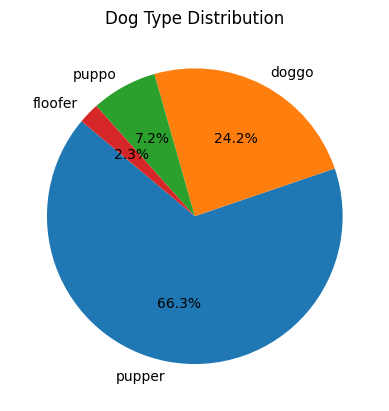

In [396]:
dog_type_data = df[df['dog_type'] != 'None']['dog_type'].value_counts()
plt.pie(dog_type_data, labels=dog_type_data.index, autopct='%1.1f%%', startangle=140)
plt.title('Dog Type Distribution')
plt.show()

**most ratings are between 0 and 125**

C:\Users\Hp\AppData\Local\Temp\ipykernel_19772\614243564.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['rating_numerator'], shade=True, color='r')
c:\Users\Hp\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


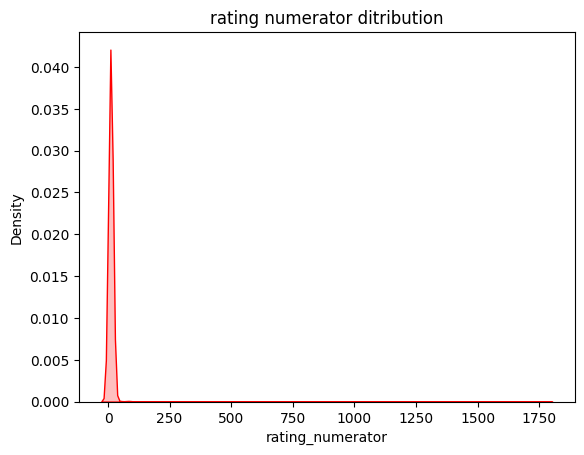

In [397]:
sns.kdeplot(df['rating_numerator'], shade=True, color='r')
plt.title('rating numerator ditribution')
plt.show()

most of the tweets from are from iphone device

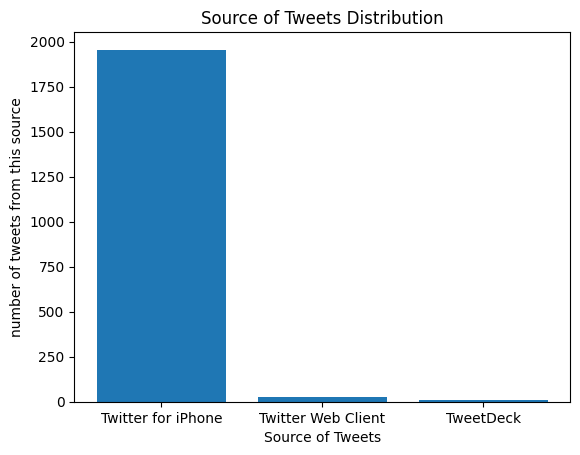

In [398]:
source_of_tweets = df['source_of_tweet'].value_counts()
plt.bar(source_of_tweets.index, source_of_tweets.values)
plt.title('Source of Tweets Distribution')
plt.xlabel('Source of Tweets')
plt.ylabel('number of tweets from this source')
plt.show()

we can see that most of the first guesses from the neural network was true

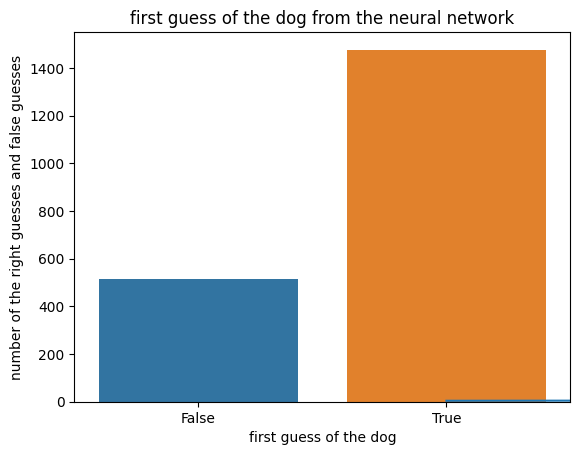

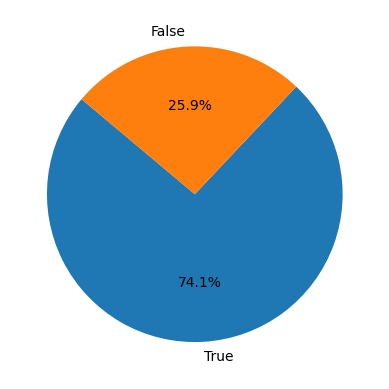

In [399]:
df['p1_dog'].value_counts()
plt.figure()
plt.plot([1, 2, 3], [4, 5, 6])
sns.countplot(x='p1_dog',data=df)
plt.xlabel('first guess of the dog')
plt.ylabel('number of the right guesses and false guesses')
plt.title('first guess of the dog from the neural network')
plt.figure()
plt.plot([1, 2, 3], [4, 5, 6])
plt.pie(df['p1_dog'].value_counts(), labels=df['p1_dog'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.show()

there is a direct relation between the time and the favourite count and from this visuallization we can conclude that the account's popularity and the lovers of this content are increasing

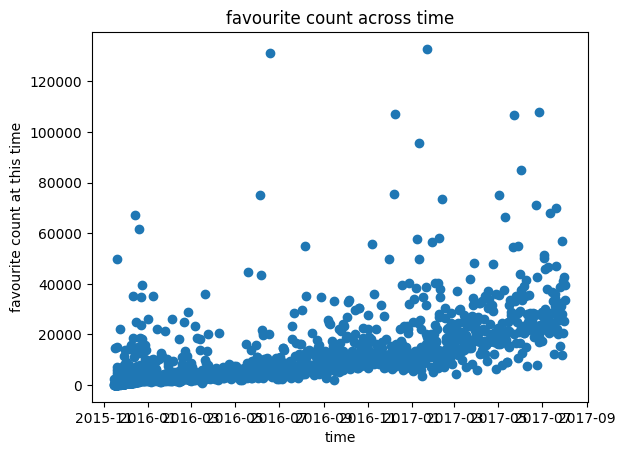

In [400]:
plt.scatter(df['created_at'],df['favorite_count'])
plt.title('favourite count across time')
plt.xlabel('time')
plt.ylabel('favourite count at this time')
plt.show()

as we can see the most loved dog type is puppo

Text(0, 0.5, 'average favourite count')

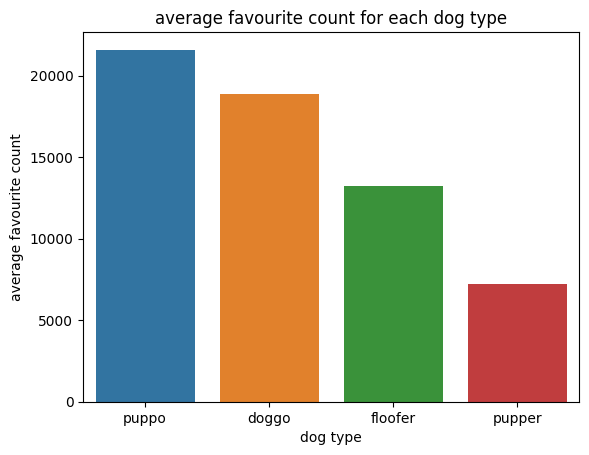

In [401]:
dog_type_favorited = df[df['dog_type'] != 'None'].groupby('dog_type')['favorite_count'].mean().sort_values(ascending=False)
sns.barplot(x=dog_type_favorited.index, y=dog_type_favorited.values)
plt.title('average favourite count for each dog type')
plt.xlabel('dog type')
plt.ylabel('average favourite count')

## Making the model and training it stage:

here i choosed logistic regression model as it can handle many input parameters to output one parameter unlike a model like naive bayes

this model takes the input columns 'favorite_count','rating_numerator' and is trained on them to predict which type of dog type is this dog based on these inputs and it achieved an accuracy of around 67%

In [402]:
model = LogisticRegression()
dog_type_pred = df[df['dog_type'] != 'None']
x = dog_type_pred[['favorite_count','rating_numerator']]
y = dog_type_pred['dog_type']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.6774193548387096


**Thank you for your time of reviewing my work and i really appreciate that and i hope if you would like to add resources or anything related to data science or deep learning to be more skilled**